### Final Capstone Project: Azure Databricks
**End-to-End Retail Analytics Platform**

In [0]:
dbutils.fs.mkdirs("/FileStore/tables/retail_raw/")

True

Part 1: Ingestion


In [0]:
customers_data = """customer_id,customer_name,city,state,customer_type
C101, Rahul Sharma, Hyderabad, Telangana, Premium
C102, Priya Reddy, Bangalore, Karnataka, Regular
C103, Amit Kumar, Mumbai, Maharashtra, Regular
C104, Sneha Patel, Delhi, Delhi, Premium
C105, Farhan Ali, Chennai, Tamil Nadu, Regular
C106, Neha Singh, Pune, Maharashtra, Premium
C107, Arjun Verma, Hyderabad, Telangana, Regular
C108, Meera Nair, Kochi, Kerala, Premium"""
dbutils.fs.put("/FileStore/tables/retail_raw/customers.csv", customers_data, overwrite=True)

products_data = """product_id,product_name,category,unit_price
P101, Laptop, Electronics, 65000
P102, Mobile, Electronics, 25000
P103, Chair, Furniture, 7000
P104, Table, Furniture, 12000
P105, Shoes, Fashion, 4500
P106, Watch, Fashion, 8000
P107, TV, Electronics, 45000
P108, Bag, Fashion, 3000"""
dbutils.fs.put("/FileStore/tables/retail_raw/products.csv", products_data, overwrite=True)

orders_data = """order_id,customer_id,product_id,order_date,quantity,status
01001, C101, P101,2026-06-01, 1, Completed
01002,C102, P102,2026-06-01,2, Completed
01003, C103,P103,2026-06-02, 3, Pending
01004,C104,P104,2026-06-02,2, Completed
01005,C105,P105,2026-06-03,4, Cancelled
01006, C106,P106,2026-06-03,1,Completed
01007,C107,P107,2026-06-04,1,Completed
01008,C108,P108,2026-06-04,5, Completed
01009,C101,P102,2026-06-05, 1, Completed
01010,C104,P101,2026-06-05,1,Completed"""
dbutils.fs.put("/FileStore/tables/retail_raw/orders.csv", orders_data, overwrite=True)

preferences_data = """[
  {
    "customer_id": "C101",
    "preferred_channel": "Online",
    "loyalty": {
      "tier": "Gold",
      "points": 1200
    }
  },
  {
    "customer_id": "C102",
    "preferred_channel": "Store",
    "loyalty": {
      "tier": "Silver",
      "points": 700
    }
  },
  {
    "customer_id": "C104",
    "preferred_channel": "Online",
    "loyalty": {
      "tier": "Platinum",
      "points": 2200
    }
  },
  {
    "customer_id": "C108",
    "preferred_channel": "Mobile App",
    "loyalty": {
      "tier": "Gold",
      "points": 1500
    }
  }
]"""
dbutils.fs.put("/FileStore/tables/retail_raw/customer_preferences.json", preferences_data, overwrite=True)

print("Files created!")

Wrote 419 bytes.
Wrote 276 bytes.
Wrote 461 bytes.
Wrote 558 bytes.
Files created!


In [0]:
customers_df = spark.read.csv("/FileStore/tables/retail_raw/customers.csv", header=True, inferSchema=True)
display(customers_df)

products_df = spark.read.csv("/FileStore/tables/retail_raw/products.csv", header=True, inferSchema=True)
display(products_df)

orders_df = spark.read.csv("/FileStore/tables/retail_raw/orders.csv", header=True, inferSchema=True)
display(orders_df)

preferences_df = spark.read.option("multiline", "true").json("/FileStore/tables/retail_raw/customer_preferences.json")
display(preferences_df)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000.0
P102,Mobile,Electronics,25000.0
P103,Chair,Furniture,7000.0
P104,Table,Furniture,12000.0
P105,Shoes,Fashion,4500.0
P106,Watch,Fashion,8000.0
P107,TV,Electronics,45000.0
P108,Bag,Fashion,3000.0


order_id,customer_id,product_id,order_date,quantity,status
1001,C101,P101,2026-06-01,1.0,Completed
1002,C102,P102,2026-06-01,2.0,Completed
1003,C103,P103,2026-06-02,3.0,Pending
1004,C104,P104,2026-06-02,2.0,Completed
1005,C105,P105,2026-06-03,4.0,Cancelled
1006,C106,P106,2026-06-03,1.0,Completed
1007,C107,P107,2026-06-04,1.0,Completed
1008,C108,P108,2026-06-04,5.0,Completed
1009,C101,P102,2026-06-05,1.0,Completed
1010,C104,P101,2026-06-05,1.0,Completed


customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
customers_df.printSchema()
products_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |--  product_name: string (nullable = true)
 |--  category: string (nullable = true)
 |--  unit_price: double (nullable = true)

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |--  quantity: double (nullable = true)
 |--  status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customers")
products_df.write.format("delta").mode("overwrite").saveAsTable("bronze_products")
orders_df.write.format("delta").mode("overwrite").saveAsTable("bronze_orders")
preferences_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customer_preferences")

Part 2: Cleaning and Transformation


In [0]:
from pyspark.sql.functions import *

customers_cleaned = customers_df.na.drop(subset=["customer_id"])
display(customers_cleaned)

products_cleaned = products_df.na.drop(subset=["product_id"])
display(products_cleaned)

orders_cleaned = orders_df.na.drop(subset=["order_id"])
display(orders_cleaned)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000.0
P102,Mobile,Electronics,25000.0
P103,Chair,Furniture,7000.0
P104,Table,Furniture,12000.0
P105,Shoes,Fashion,4500.0
P106,Watch,Fashion,8000.0
P107,TV,Electronics,45000.0
P108,Bag,Fashion,3000.0


order_id,customer_id,product_id,order_date,quantity,status
1001,C101,P101,2026-06-01,1.0,Completed
1002,C102,P102,2026-06-01,2.0,Completed
1003,C103,P103,2026-06-02,3.0,Pending
1004,C104,P104,2026-06-02,2.0,Completed
1005,C105,P105,2026-06-03,4.0,Cancelled
1006,C106,P106,2026-06-03,1.0,Completed
1007,C107,P107,2026-06-04,1.0,Completed
1008,C108,P108,2026-06-04,5.0,Completed
1009,C101,P102,2026-06-05,1.0,Completed
1010,C104,P101,2026-06-05,1.0,Completed


In [0]:
flattened_preferences = preferences_df.select(
    col("customer_id"),
    col("preferred_channel"),
    col("loyalty.tier").alias("loyalty_tier"),
    col("loyalty.points").alias("loyalty_points")
)
display(flattened_preferences)

customer_id,preferred_channel,loyalty_tier,loyalty_points
C101,Online,Gold,1200
C102,Store,Silver,700
C104,Online,Platinum,2200
C108,Mobile App,Gold,1500


In [0]:
cust_pref = customers_cleaned.join(flattened_preferences, "customer_id", "left")
display(cust_pref)

cust_pref_cleaned = cust_pref.na.fill({
    "preferred_channel": "Not Provided",
    "loyalty_tier": "None",
    "loyalty_points": 0
})
display(cust_pref_cleaned)

customer_id,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


customer_id,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,Not Provided,None,0
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,Not Provided,None,0
C106,Neha Singh,Pune,Maharashtra,Premium,Not Provided,None,0
C107,Arjun Verma,Hyderabad,Telangana,Regular,Not Provided,None,0
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
odr_cust = orders_cleaned.join(customers_cleaned, "customer_id", "inner")
display(odr_cust)

odr_prod = odr_cust.join(products_cleaned, "product_id", "inner")
display(odr_prod)

customer_id,order_id,product_id,order_date,quantity,status,customer_name,city,state,customer_type
C102,1002,P102,2026-06-01,2.0,Completed,Priya Reddy,Bangalore,Karnataka,Regular
C104,1004,P104,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium
C105,1005,P105,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular
C107,1007,P107,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular
C108,1008,P108,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium
C101,1009,P102,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C104,1010,P101,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000.0
P105,C105,1005,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500.0
P107,C107,1007,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000.0
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000.0
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000.0
P101,C104,1010,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000.0


In [0]:
print("Creating Revenue Column:")
rev = odr_prod.withColumn("revenue", col("quantity") * col("unit_price"))
display(rev)

print("Creating order_month column:")
odr_mon = odr_prod.withColumn("order_month", month(col("order_date")))
display(odr_mon)

print("Creating customer_segment column:")
cust_seg = odr_prod.withColumn("customer_segment", when(col("customer_type") == " Premium", "High Value").otherwise("Standard Value"))
display(cust_seg)

Creating Revenue Column:


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000.0,24000.0
P105,C105,1005,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500.0,18000.0
P107,C107,1007,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000.0,45000.0
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000.0,15000.0
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000.0,25000.0
P101,C104,1010,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000.0,65000.0


Creating order_month column:


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,order_month
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000.0,6
P105,C105,1005,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500.0,6
P107,C107,1007,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000.0,6
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000.0,6
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000.0,6
P101,C104,1010,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000.0,6


Creating customer_segment column:


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,customer_segment
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000.0,High Value
P105,C105,1005,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500.0,Standard Value
P107,C107,1007,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000.0,Standard Value
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000.0,High Value
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000.0,High Value
P101,C104,1010,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000.0,High Value


In [0]:
customers_cleaned.write.format("delta").mode("overwrite").saveAsTable("silver_customers")
products_cleaned.write.format("delta").mode("overwrite").saveAsTable("silver_products")
odr_prod.write.format("delta").mode("overwrite").saveAsTable("silver_orders")
flattened_preferences.write.format("delta").mode("overwrite").saveAsTable("silver_customer_preferences")

Part 3: Spark SQL


In [0]:
overall_data =  orders_cleaned.join(cust_pref_cleaned, on="customer_id", how="inner").join(products_cleaned, on="product_id", how="inner")

overall_data = overall_data.withColumn("revenue", col("quantity") * col("unit_price")).withColumn("order_month", date_format(col("order_date"), "yyyy-MM")).withColumn("customer_segment", when(col("customer_type") == "Premium", "High Value").otherwise("Standard Value"))

display(overall_data)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points,product_name,category,unit_price,revenue,order_month,customer_segment
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000.0,25000.0,2026-06,Standard Value
P101,C104,1010,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000.0,65000.0,2026-06,Standard Value
P105,C105,1005,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Not Provided,None,0,Shoes,Fashion,4500.0,18000.0,2026-06,Standard Value
P107,C107,1007,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular,Not Provided,None,0,TV,Electronics,45000.0,45000.0,2026-06,Standard Value
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000.0,15000.0,2026-06,Standard Value
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000.0,24000.0,2026-06,Standard Value


In [0]:
overall_data.createOrReplaceTempView("v_overall_data")

print("Total Revenue:")
spark.sql("SELECT SUM(revenue) AS total_revenue FROM v_overall_data").show()

print("Total Revenue by City:")
spark.sql("SELECT city, SUM(revenue) AS total_revenue_by_city FROM v_overall_data GROUP BY city ORDER BY total_revenue_by_city DESC").show()

print("Total Revenue by Category:")
spark.sql("SELECT category, SUM(revenue) AS total_revenue_by_category FROM v_overall_data GROUP BY category ORDER BY total_revenue_by_category DESC").show()

print("Top Customers:")
spark.sql("SELECT customer_name, SUM(revenue) AS total_revenue FROM v_overall_data GROUP BY customer_name ORDER BY total_revenue DESC LIMIT 5").show()

print("Completed Orders:")
spark.sql("SELECT * FROM v_overall_data WHERE status = ' Completed'").display()

Total Revenue:
+-------------+
|total_revenue|
+-------------+
|     192000.0|
+-------------+

Total Revenue by City:
+----------+---------------------+
|      city|total_revenue_by_city|
+----------+---------------------+
|     Delhi|              89000.0|
| Hyderabad|              70000.0|
|   Chennai|              18000.0|
|     Kochi|              15000.0|
+----------+---------------------+

Total Revenue by Category:
+------------+-------------------------+
|    category|total_revenue_by_category|
+------------+-------------------------+
| Electronics|                 135000.0|
|     Fashion|                  33000.0|
|   Furniture|                  24000.0|
+------------+-------------------------+

Top Customers:
+-------------+-------------+
|customer_name|total_revenue|
+-------------+-------------+
|  Sneha Patel|      89000.0|
|  Arjun Verma|      45000.0|
| Rahul Sharma|      25000.0|
|   Farhan Ali|      18000.0|
|   Meera Nair|      15000.0|
+-------------+-------------+


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points,product_name,category,unit_price,revenue,order_month,customer_segment
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000.0,25000.0,2026-06,Standard Value
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000.0,24000.0,2026-06,Standard Value
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000.0,15000.0,2026-06,Standard Value


Part 4: Window Functions


In [0]:
from pyspark.sql.window import Window
prod_window = Window.orderBy(col("total_prod_revenue").desc())
prod_revenue_df = overall_data.groupBy("product_name").agg(sum("revenue").alias("total_prod_revenue"))
print("Rank products by revenue:")
prod_revenue_df.withColumn("rank", rank().over(prod_window)).show()

Rank products by revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+------------------+----+
|product_name|total_prod_revenue|rank|
+------------+------------------+----+
|      Laptop|           65000.0|   1|
|          TV|           45000.0|   2|
|      Mobile|           25000.0|   3|
|       Table|           24000.0|   4|
|       Shoes|           18000.0|   5|
|         Bag|           15000.0|   6|
+------------+------------------+----+



In [0]:
cust_window = Window.orderBy(col("total_cust_revenue").desc())
cust_revenue_df = overall_data.groupBy("customer_name").agg(sum("revenue").alias("total_cust_revenue"))
print("Rank Customers by revenue:")
cust_revenue_df.withColumn("rank", rank().over(cust_window)).display()

print("Top 3 Customers:")
ranked_cust_df.filter(col("rank") <= 3).show()

Rank Customers by revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_name,total_cust_revenue,rank
Sneha Patel,89000.0,1
Arjun Verma,45000.0,2
Rahul Sharma,25000.0,3
Farhan Ali,18000.0,4
Meera Nair,15000.0,5


Top 3 Customers:
+-------------+------------------+----+
|customer_name|total_cust_revenue|rank|
+-------------+------------------+----+
|  Sneha Patel|           89000.0|   1|
|  Arjun Verma|           45000.0|   2|
| Rahul Sharma|           25000.0|   3|
+-------------+------------------+----+



In [0]:
cat_prod_window = Window.partitionBy("category").orderBy(col("total_cat_prod_revenue").desc())
cat_prod_rev = overall_data.groupBy("category", "product_name").agg(sum("revenue").alias("total_cat_prod_revenue"))
print("Top Product in each Category:")
cat_prod_rev.withColumn("rank", rank().over(cat_prod_window)).filter(col("rank") == 1).show()

Top Product in each Category:
+------------+------------+----------------------+----+
|    category|product_name|total_cat_prod_revenue|rank|
+------------+------------+----------------------+----+
| Electronics|      Laptop|               65000.0|   1|
|     Fashion|       Shoes|               18000.0|   1|
|   Furniture|       Table|               24000.0|   1|
+------------+------------+----------------------+----+



In [0]:
running_window = Window.orderBy("order_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
daily_revenue = overall_data.groupBy("order_date").agg(sum("revenue").alias("daily_revenue"))
print("Running Revenue:")
daily_revenue.withColumn("running_revenue", sum("daily_revenue").over(running_window)).orderBy("order_date").show()

Running Revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-------------+---------------+
|order_date|daily_revenue|running_revenue|
+----------+-------------+---------------+
|2026-06-02|      24000.0|        24000.0|
|2026-06-03|      18000.0|        42000.0|
|2026-06-04|      60000.0|       102000.0|
|2026-06-05|      90000.0|       192000.0|
+----------+-------------+---------------+



Part 5: Delta Lake


In [0]:
overall_data.write.format("delta").mode("overwrite").save("/mnt/delta/orders_df_path")

In [0]:
overall_data.write.format("delta").mode("overwrite").saveAsTable("delta_orders_table")

In [0]:
%sql
CREATE TABLE IF NOT EXISTS delta_sql_table (order_id STRING, customer_id STRING, revenue DOUBLE) USING DELTA;

In [0]:
print("Delta history:")
spark.sql("DESCRIBE HISTORY delta_orders_table").display()

Delta history:


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T05:36:20.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1681479533029079),ada7adda-07de-4a69-ac93-94a01a94e8e2,0622-041217-o9jc06bu-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 6, numOutputBytes -> 5772)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
print("Previous Version using Time Travel:")
spark.sql("SELECT * FROM delta_orders_table VERSION AS OF 0").display()

Previous Version using Time Travel:


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points,product_name,category,unit_price,revenue,order_month,customer_segment
P102,C101,1009,2026-06-05,1.0,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000.0,25000.0,2026-06,Standard Value
P101,C104,1010,2026-06-05,1.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000.0,65000.0,2026-06,Standard Value
P105,C105,1005,2026-06-03,4.0,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Not Provided,None,0,Shoes,Fashion,4500.0,18000.0,2026-06,Standard Value
P107,C107,1007,2026-06-04,1.0,Completed,Arjun Verma,Hyderabad,Telangana,Regular,Not Provided,None,0,TV,Electronics,45000.0,45000.0,2026-06,Standard Value
P108,C108,1008,2026-06-04,5.0,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000.0,15000.0,2026-06,Standard Value
P104,C104,1004,2026-06-02,2.0,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000.0,24000.0,2026-06,Standard Value


In [0]:
update_payload = [("C101", "Rahul Sharma", "Hyderabad", "Telangana", "Premium", "Online", "Gold", 1600)]
schema_cols = ["customer_id", "customer_name", "city", "state", "customer_type", "preferred_channel", "loyalty_tier", "loyalty_points"]
updated_cust_df = spark.createDataFrame(update_payload, schema_cols)

In [0]:
overall_data.write.format("delta").mode("overwrite").saveAsTable("silver_customer_profiles")

In [0]:
from delta.tables import DeltaTable
target_table = DeltaTable.forName(spark, "silver_customer_profiles")

update_mapping = {
    "customer_name": "source.customer_name",
    "city": "source.city",
    "state": "source.state",
    "customer_type": "source.customer_type",
    "preferred_channel": "source.preferred_channel",
    "loyalty_tier": "source.loyalty_tier",
    "loyalty_points": "source.loyalty_points"
}

insert_mapping = {
    "customer_id": "source.customer_id",
    "customer_name": "source.customer_name",
    "city": "source.city",
    "state": "source.state",
    "customer_type": "source.customer_type",
    "preferred_channel": "source.preferred_channel",
    "loyalty_tier": "source.loyalty_tier",
    "loyalty_points": "source.loyalty_points"
}

target_table.alias("target").merge(
      source=updated_cust_df.alias("source"), 
      condition="target.customer_id = source.customer_id"
  ).whenMatchedUpdate(set=update_mapping).whenNotMatchedInsert(values=insert_mapping).execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
print("After Merge, Verifying History:")
spark.sql("DESCRIBE HISTORY silver_customer_profiles").select("version", "operation", "timestamp").show(2)

After Merge, Verifying History:
+-------+---------+-------------------+
|version|operation|          timestamp|
+-------+---------+-------------------+
|      2| OPTIMIZE|2026-06-22 05:44:28|
|      1|    MERGE|2026-06-22 05:44:26|
+-------+---------+-------------------+
only showing top 2 rows


In [0]:
print("Optimize:")
spark.sql("OPTIMIZE silver_customer_profiles").display()

print("ZORDER by City:")
spark.sql("OPTIMIZE silver_customer_profiles ZORDER BY (city)").display()

print("Vacuum:")
spark.sql("VACUUM silver_customer_profiles").display()

Optimize:


path,metrics
abfss://unity-catalog-storage@dbstoragej5qj2n5qqfs2c.dfs.core.windows.net/7405617305956028/__unitystorage/catalogs/620d2a81-0d64-4794-a6ea-1199ce3fe40a/tables/d0af9959-03b6-414f-b1e8-12ec6c2ffff2,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782107284608, 1782107284970, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


ZORDER by City:


path,metrics
abfss://unity-catalog-storage@dbstoragej5qj2n5qqfs2c.dfs.core.windows.net/7405617305956028/__unitystorage/catalogs/620d2a81-0d64-4794-a6ea-1199ce3fe40a/tables/d0af9959-03b6-414f-b1e8-12ec6c2ffff2,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5823), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782107285689, 1782107286062, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


Vacuum:


path
abfss://unity-catalog-storage@dbstoragej5qj2n5qqfs2c.dfs.core.windows.net/7405617305956028/__unitystorage/catalogs/620d2a81-0d64-4794-a6ea-1199ce3fe40a/tables/d0af9959-03b6-414f-b1e8-12ec6c2ffff2


Part 6: Visualization

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
pdf = spark.sql("""SELECT city, category, status, product_name, order_date, SUM(revenue) AS revenue, COUNT(order_id) AS total_orders
        FROM v_overall_data GROUP BY city, category, status, product_name, order_date""").toPandas()

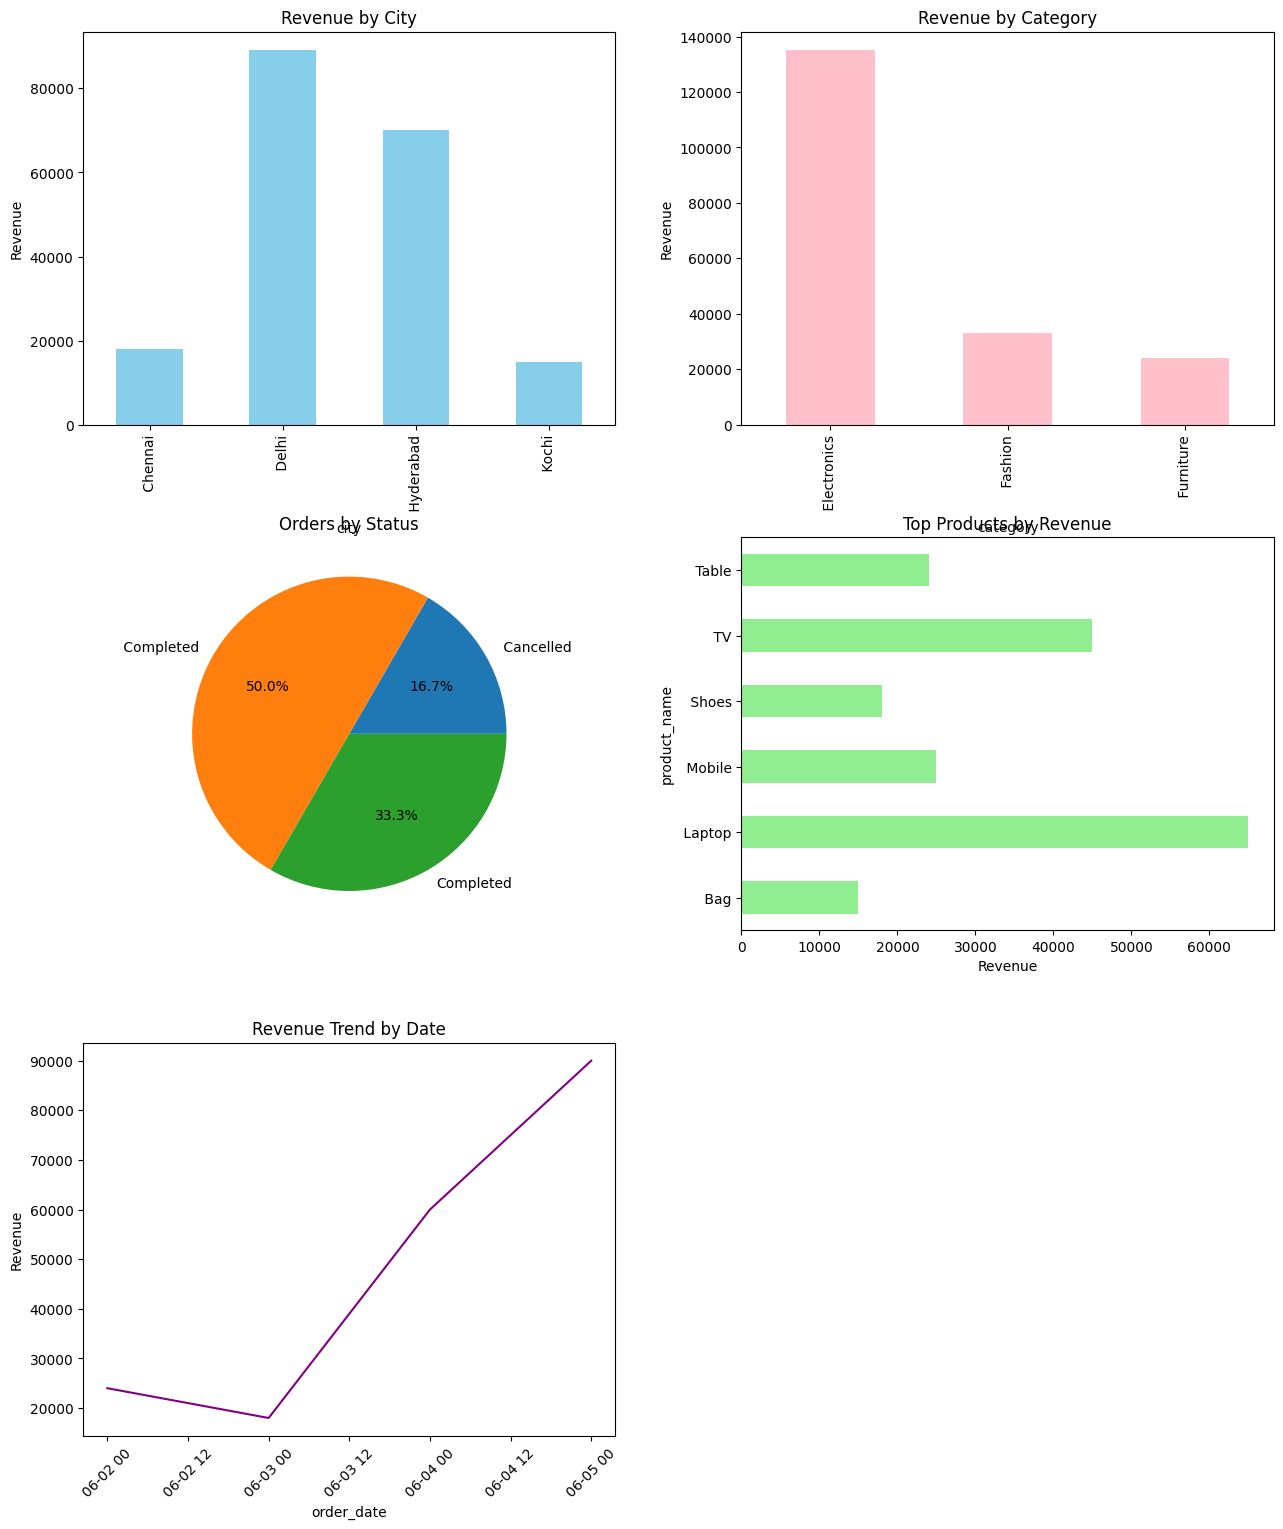

In [0]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.tight_layout(pad=6.0)

pdf.groupby('city')['revenue'].sum().plot(kind='bar', ax=axes[0,0], color='skyblue', title='Revenue by City')
axes[0,0].set_ylabel('Revenue')

pdf.groupby('category')['revenue'].sum().plot(kind='bar', ax=axes[0,1], color='pink', title='Revenue by Category')
axes[0,1].set_ylabel('Revenue')

pdf.groupby('status')['total_orders'].sum().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', title='Orders by Status')
axes[1,0].set_ylabel('')

pdf.groupby('product_name')['revenue'].sum().plot(kind='barh', ax=axes[1,1], color='lightgreen', title='Top Products by Revenue')
axes[1,1].set_xlabel('Revenue')

pdf.groupby('order_date')['revenue'].sum().plot(kind='line', ax=axes[2,0], color='purple', title='Revenue Trend by Date')
axes[2,0].set_ylabel('Revenue')
axes[2,0].tick_params(axis='x', rotation=45)

axes[2,1].axis('off')
plt.show()

Part 7: Tables and Views


In [0]:
%sql
CREATE TABLE IF NOT EXISTS managed_retail_summary AS 
SELECT city, sum(revenue) as total_rev FROM v_overall_data GROUP BY city;

SELECT * FROM managed_retail_summary

city,total_rev
Chennai,18000.0
Delhi,89000.0
Hyderabad,70000.0
Kochi,15000.0


In [0]:
%sql
CREATE TABLE IF NOT EXISTS external_retail_summary USING DELTA AS SELECT city, sum(revenue) as total_rev FROM v_overall_data GROUP BY city;

SELECT * FROM external_retail_summary;

city,total_rev
Chennai,18000.0
Delhi,89000.0
Hyderabad,70000.0
Kochi,15000.0


In [0]:
overall_data.createOrReplaceTempView("overall_data")

In [0]:
overall_data.createOrReplaceGlobalTempView("global_view_overall_data")

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5738292806687977>, line 1
----> 1 overall_data.createOrReplaceGlobalTempView("global_view_overall_data")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2129, in DataFrame.createOrReplaceGlobalTempView(self, name)
   2125 def createOrReplaceGlobalTempView(self, name: str) -> None:
   2126     command = plan.CreateView(
   2127         child=self._plan, name=name, is_global=True, replace=True
   2128     ).command(session=self._session.client)
-> 2129     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2130     self._execution_info = ei

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
   1536     req.user_context.u

In [0]:
# SCOPE AND LIFETIME COMPARISON
# 1. MANAGED TABLE:
#    Scope: Global (Visible across all workspaces, notebooks, and clusters in the metastore).
#    Lifetime: Persistent (Survives cluster restarts; DROP deletes both metadata and raw files).

# 2. EXTERNAL TABLE:
#    Scope: Global (Visible across all workspaces, notebooks, and clusters in the metastore).
#    Lifetime: Persistent (Survives cluster restarts; DROP deletes ONLY metadata, raw cloud data remains).

# 3. TEMPORARY VIEW:
#    Scope: Session-scoped (Only visible within the specific notebook/spark session that created it).
#    Lifetime: Transient (Automatically dropped when the notebook is detached or cluster restarts).

# 4. GLOBAL TEMPORARY VIEW:
#    Scope: Cluster-scoped (Visible to any notebook or session attached to the SAME running cluster).
#    Lifetime: Transient (Dropped only when the underlying compute cluster restarts or terminates).